In [ ]:
import kagglehub
import os # Import os module

# Download latest version
path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 896M/896M [00:43<00:00, 21.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nirmalsankalana/plantdoc-dataset/versions/7
Contents of base_path (/root/.cache/kagglehub/datasets/nirmalsankalana/plantdoc-dataset/versions):
['7']
Contents of path (/root/.cache/kagglehub/datasets/nirmalsankalana/plantdoc-dataset/versions/7):
['file_renamer.py', 'train', 'folder_renamer.py', 'test']


In [ ]:
import tensorflow as tf
import os

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF or check your Colab runtime settings.")

Num GPUs Available:  1
Default GPU Device: /device:GPU:0


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define constants
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 2 # Adjust based on your dataset, changed from 43 to 2

# Data preprocessing and augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Assuming 'path' contains the dataset from the previous cell
train_generator = train_datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

# Build DenseNet Model
with tf.device('/GPU:0'):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False # Freeze base model

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Found 2338 images belonging to 2 classes.
Found 584 images belonging to 2 classes.


In [ ]:
# Train the model
epochs = 10
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)

# Summarize final results
final_loss, final_accuracy = model.evaluate(validation_generator)
print(f"Final Validation Loss: {final_loss:.4f}")
print(f"Final Validation Accuracy: {final_accuracy:.4f}")

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.8952 - loss: 0.3659 - val_accuracy: 0.9144 - val_loss: 0.2546
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 613ms/step - accuracy: 0.9115 - loss: 0.2831 - val_accuracy: 0.9127 - val_loss: 0.2584
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 47s 633ms/step - accuracy: 0.9136 - loss: 0.2805 - val_accuracy: 0.9075 - val_loss: 0.2601
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 46s 621ms/step - accuracy: 0.9157 - loss: 0.2622 - val_accuracy: 0.8562 - val_loss: 0.3208
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 613ms/step - accuracy: 0.9183 - loss: 0.2558 - val_accuracy: 0.9058 - val_loss: 0.2683
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 55s 733ms/step - accuracy: 0.9187 - loss: 0.2455 - val_accuracy: 0.8955 - val_loss: 0.2668
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 605ms/step - accuracy: 0.9226 - loss: 0.2367 - val_accuracy: 0.8682 - val_loss: 0.3356
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 603ms/step - accuracy: 0.9226 - loss: 0.2286 - val_accura

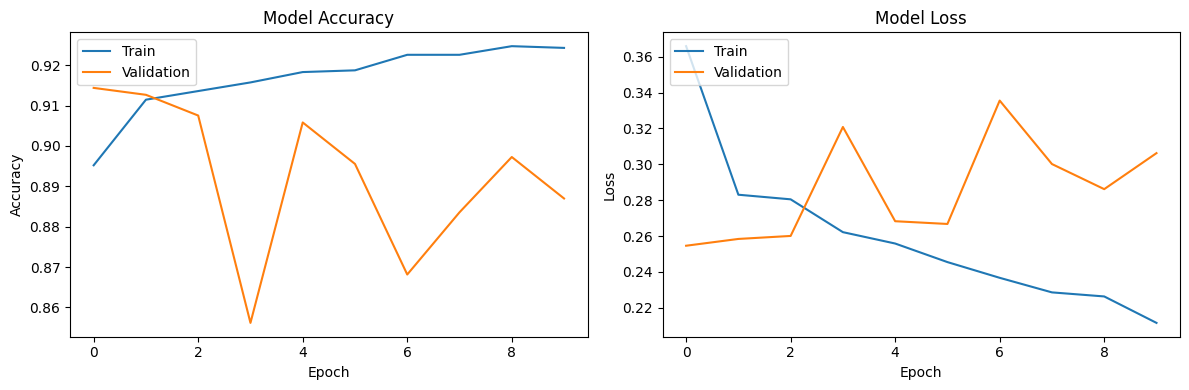

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()